In [18]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습 모델 저장을 위한 라이브러리
import pickle

# 다중공선성 확인을 위햔 라이브러리
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 기타 라이브러리
from scipy.stats import skew
from scipy.stats import norm

In [20]:
train_df = pd.read_parquet("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/ABC추출.parquet")

- train_df에 선정된 기준 : 상관계수 0.3이상 확인 후 다중공선성 확인하여 가장 높은것 하나씩 제거해가면서 5미만으로 될때까지 계산

In [24]:
train_df = train_df[['Segment','정상입금원금_B5M','청구금액_R6M','정상입금원금_B2M',
        '정상청구원금_B0M','청구금액_B0']]

train_df

,Segment,정상입금원금_B5M,청구금액_R6M,정상입금원금_B2M,정상청구원금_B0M,청구금액_B0
0,C,16949,165221,14448,21929,21866
1,C,13341,94241,11685,27704,20512
2,C,19447,108015,17025,19621,19177
3,C,17594,109620,21980,18078,22249
4,C,35949,225533,38150,31129,34826
...,...,...,...,...,...,...
128701,C,15022,96941,9888,12993,20294
128702,C,22033,126397,18938,25018,22331
128703,C,9396,132623,17814,23644,17859
128704,C,8912,72474,11092,14433,10810


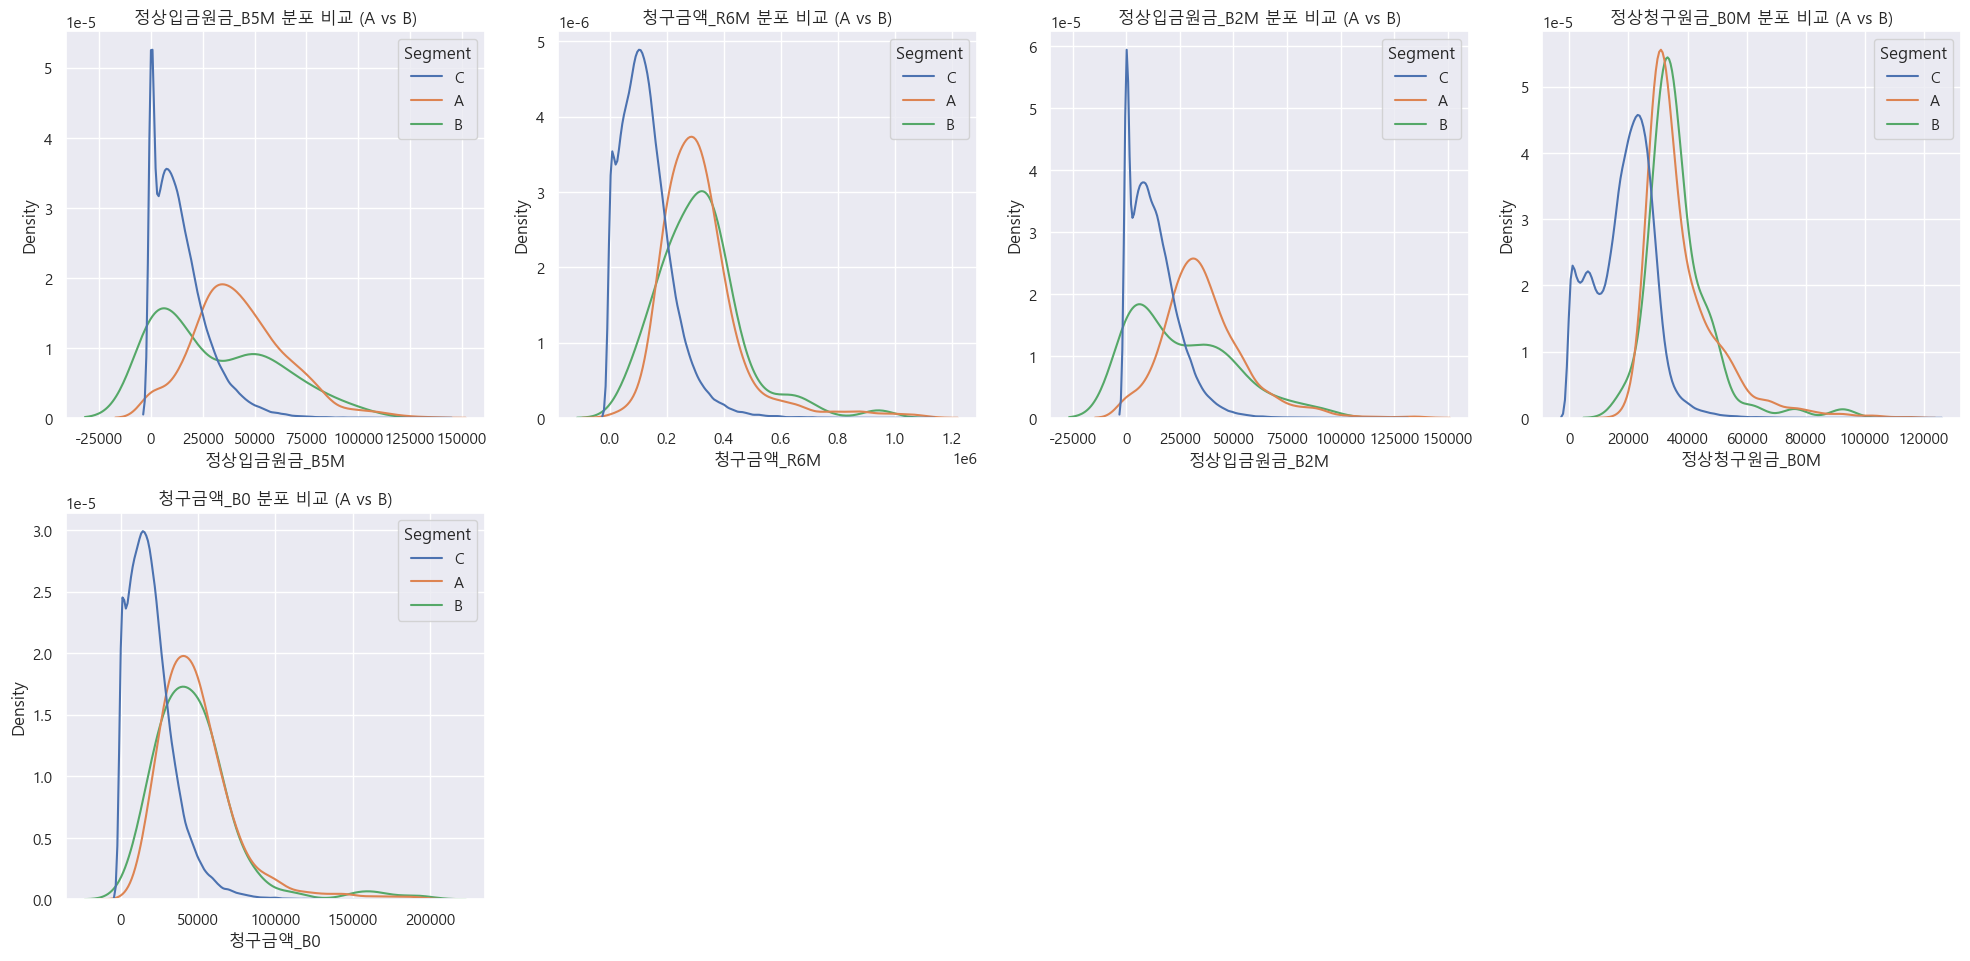

In [26]:
features = ['정상입금원금_B5M','청구금액_R6M','정상입금원금_B2M',
        '정상청구원금_B0M','청구금액_B0']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(data=train_df, x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')


plt.subplot(2, 4, 8).axis('off')

plt.tight_layout()
plt.show()

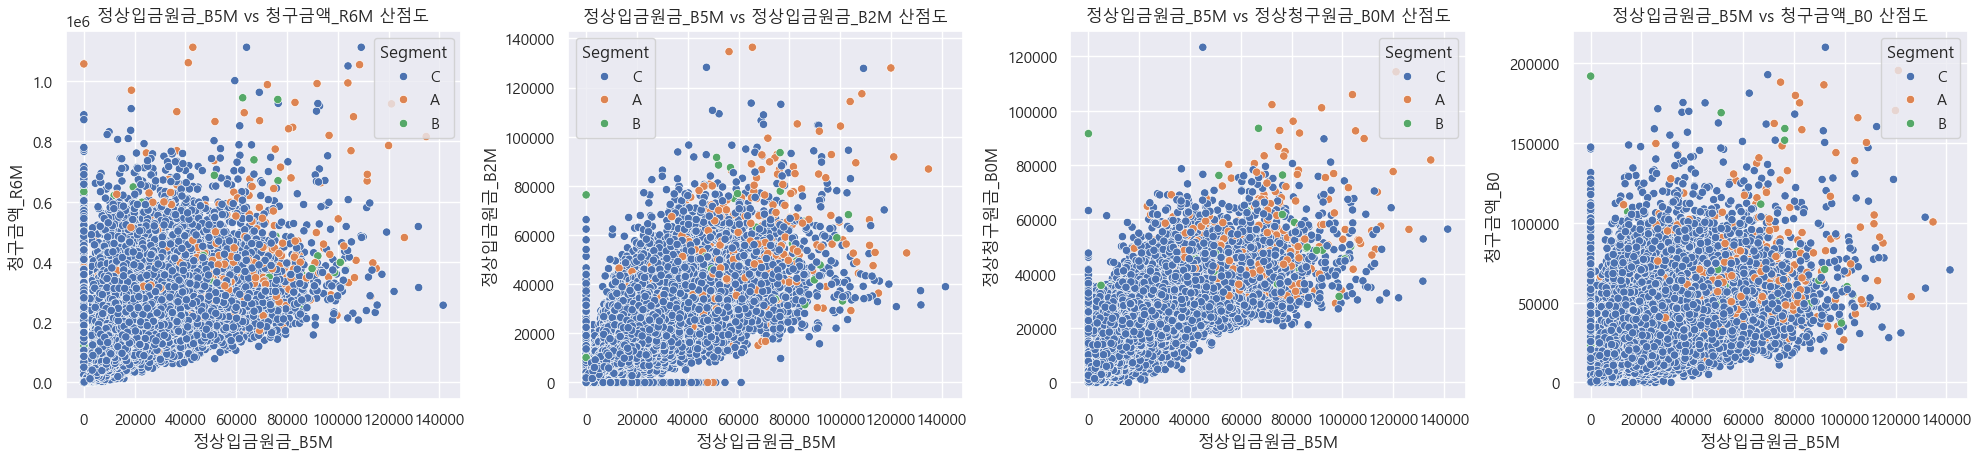

In [36]:
features = ['청구금액_R6M','정상입금원금_B2M', '정상청구원금_B0M','청구금액_B0']

plt.figure(figsize=(20, 5))

for i, f in enumerate(features):
    plt.subplot(1, 4, i + 1)
    sns.scatterplot(data=train_df, x='정상입금원금_B5M', y=f, hue='Segment')
    plt.title(f'정상입금원금_B5M vs {f} 산점도')

plt.tight_layout()
plt.show()

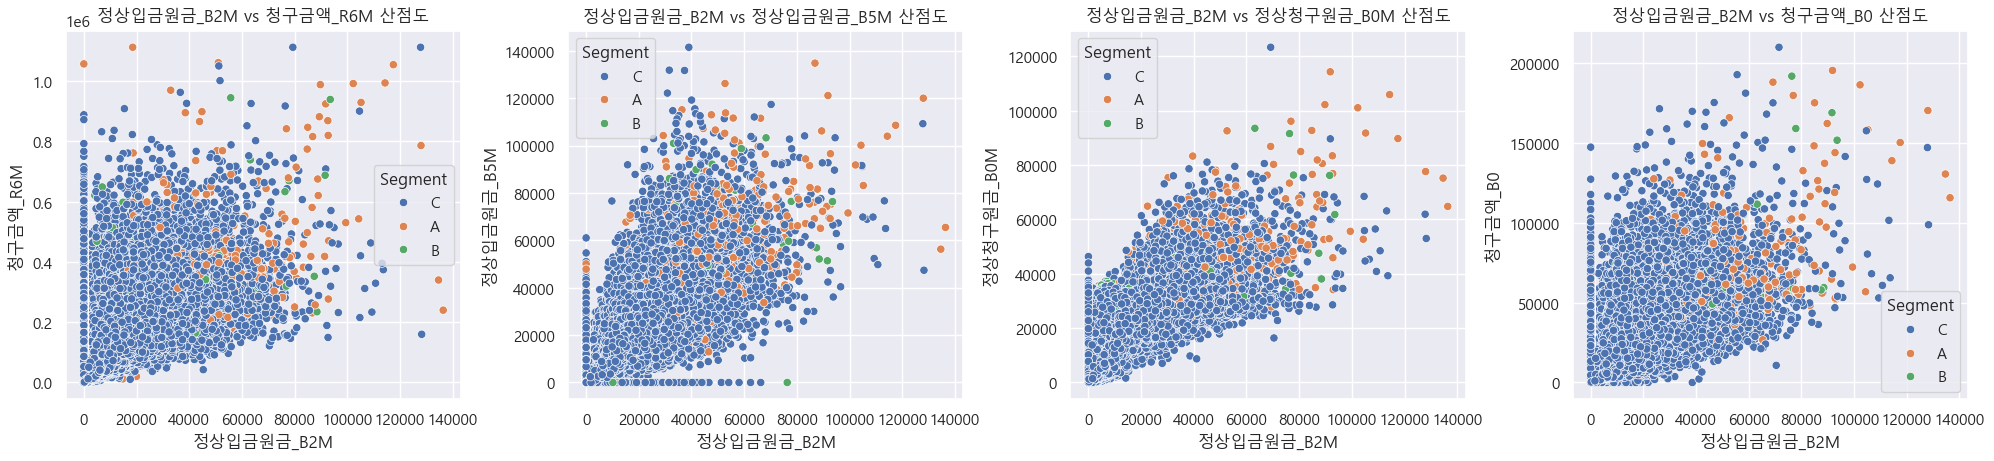

In [38]:
features = ['청구금액_R6M','정상입금원금_B5M', '정상청구원금_B0M','청구금액_B0']

plt.figure(figsize=(20, 5))

for i, f in enumerate(features):
    plt.subplot(1, 4, i + 1)
    sns.scatterplot(data=train_df, x='정상입금원금_B2M', y=f, hue='Segment')
    plt.title(f'정상입금원금_B2M vs {f} 산점도')

plt.tight_layout()
plt.show()

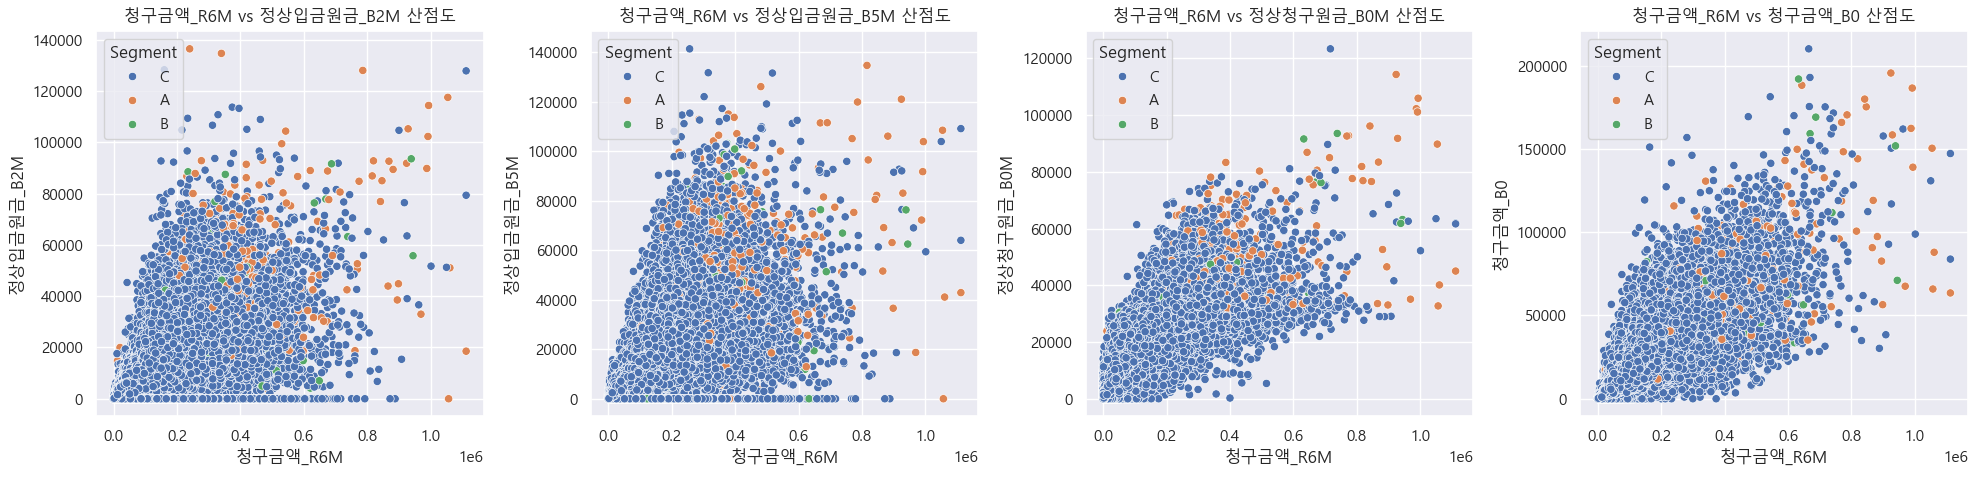

In [40]:
features = ['정상입금원금_B2M','정상입금원금_B5M', '정상청구원금_B0M','청구금액_B0']

plt.figure(figsize=(20, 5))

for i, f in enumerate(features):
    plt.subplot(1, 4, i + 1)
    sns.scatterplot(data=train_df, x='청구금액_R6M', y=f, hue='Segment')
    plt.title(f'청구금액_R6M vs {f} 산점도')

plt.tight_layout()
plt.show()

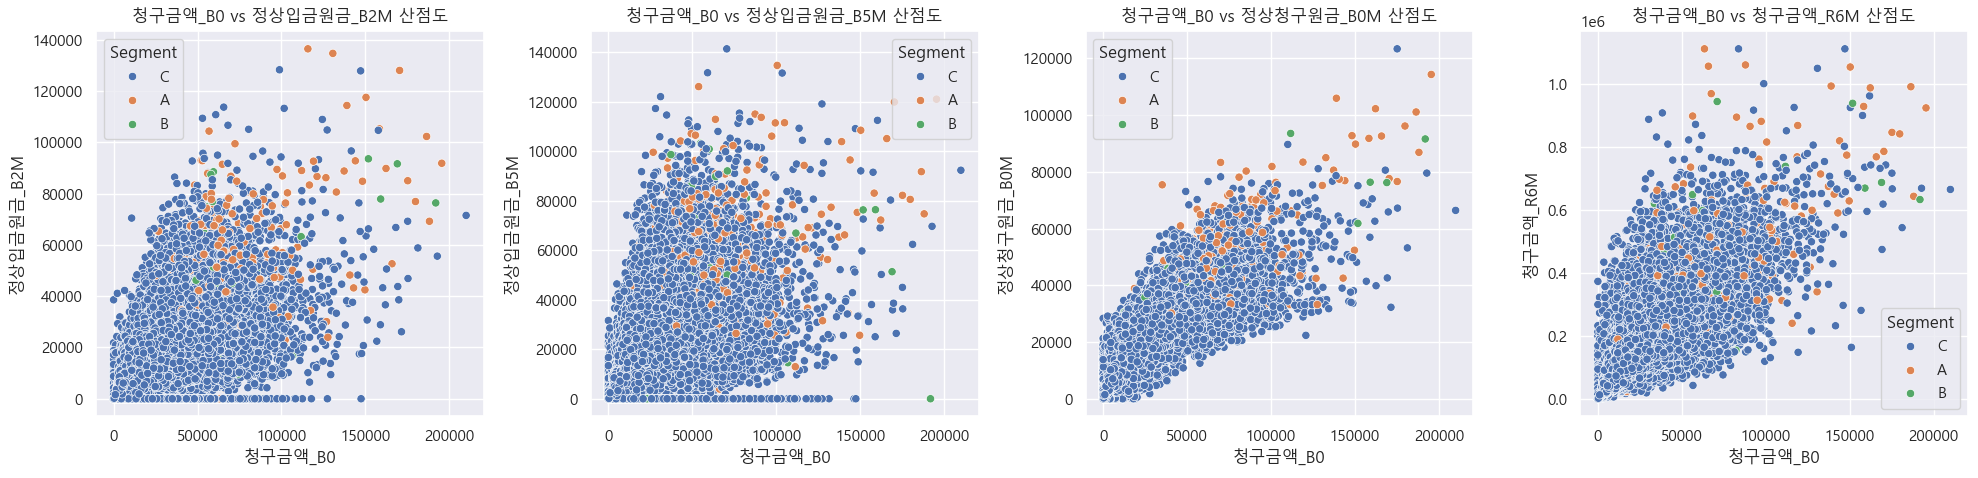

In [42]:
features = ['정상입금원금_B2M','정상입금원금_B5M', '정상청구원금_B0M','청구금액_R6M']

plt.figure(figsize=(20, 5))

for i, f in enumerate(features):
    plt.subplot(1, 4, i + 1)
    sns.scatterplot(data=train_df, x='청구금액_B0', y=f, hue='Segment')
    plt.title(f'청구금액_B0 vs {f} 산점도')

plt.tight_layout()
plt.show()

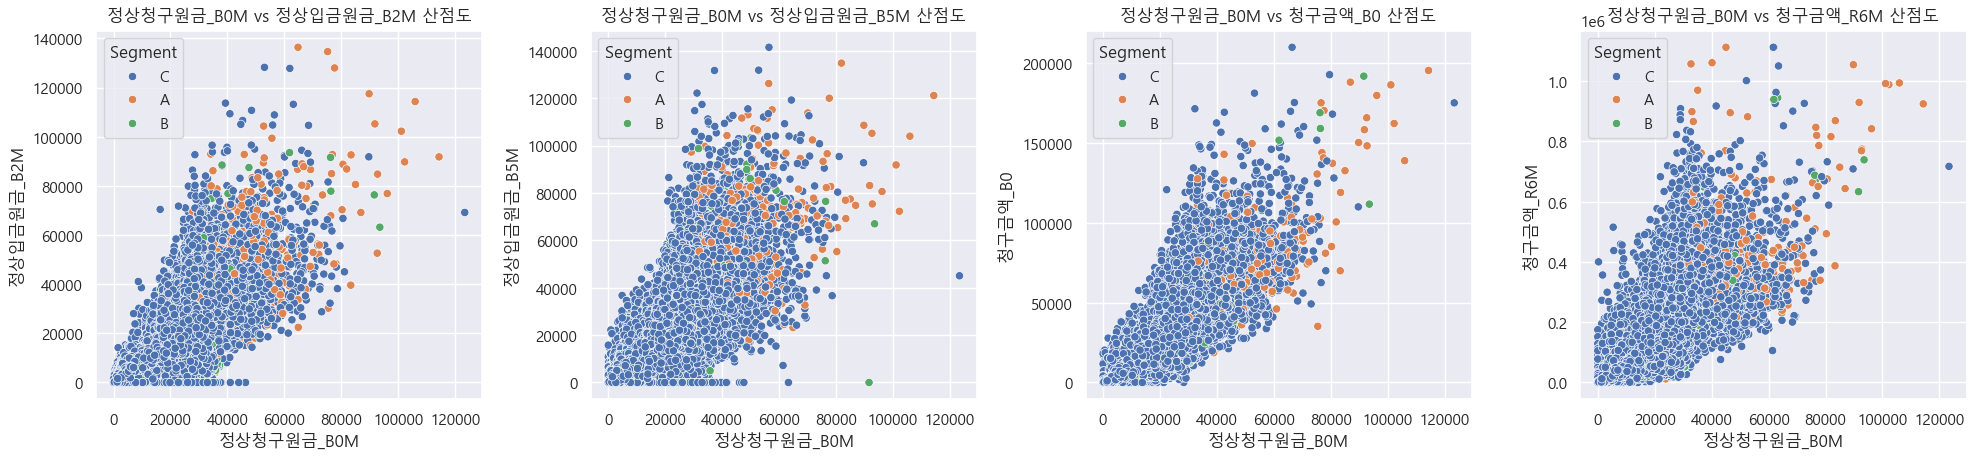

In [44]:
features = ['정상입금원금_B2M','정상입금원금_B5M', '청구금액_B0','청구금액_R6M']

plt.figure(figsize=(20, 5))

for i, f in enumerate(features):
    plt.subplot(1, 4, i + 1)
    sns.scatterplot(data=train_df, x='정상청구원금_B0M', y=f, hue='Segment')
    plt.title(f'정상청구원금_B0M vs {f} 산점도')

plt.tight_layout()
plt.show()

In [50]:
features = ['정상입금원금_B2M','정상입금원금_B5M', '청구금액_B0','청구금액_R6M','정상청구원금_B0M']

In [52]:
grouped_mean = train_df.groupby('Segment')[features].mean().T
grouped_median = train_df.groupby('Segment')[features].median().T

summary_df = pd.concat([grouped_mean, grouped_median], axis=1)
summary_df.columns = ['Mean_A', 'Mean_B','Mean_C', 'Median_A', 'Median_B','Median_C']

summary_df = summary_df.round(3)

summary_df

,Mean_A,Mean_B,Mean_C,Median_A,Median_B,Median_C
정상입금원금_B2M,36221.669,26432.604,13072.526,33692.5,22267.5,11094.0
정상입금원금_B5M,42909.624,30778.215,14374.597,40424.0,22477.0,11601.0
청구금액_B0,49514.364,47600.667,20001.545,45198.0,42928.0,17344.0
청구금액_R6M,316939.459,316174.257,128408.240,294936.0,305692.0,115177.0
정상청구원금_B0M,37794.283,36986.014,18517.785,33549.0,34224.5,19691.5
